In [ ]:
# @title
!pip install xgboost -q

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import io
import pickle
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                            StackingClassifier, BaggingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def calculate_all_metrics(y_true, y_pred, average='weighted'):
    """Calculate all classification metrics"""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=average, zero_division=0),
        'recall': recall_score(y_true, y_pred, average=average, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, average=average, zero_division=0)
    }

    # For binary classification, calculate specificity
    if len(np.unique(y_true)) == 2:
        metrics['specificity'] = calculate_specificity(y_true, y_pred)
    else:
        # For multiclass, calculate specificity for each class and average
        specificities = []
        for class_label in np.unique(y_true):
            y_true_binary = (y_true == class_label).astype(int)
            y_pred_binary = (y_pred == class_label).astype(int)
            spec = calculate_specificity(y_true_binary, y_pred_binary)
            specificities.append(spec)
        metrics['specificity'] = np.mean(specificities)

    return metrics

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:
import pandas as pd
import io
from google.colab import files

# Upload dataset
print(" Please upload your dataset:")
uploaded = files.upload()

# Automatically read the uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))



print(f"\n Dataset '{filename}' loaded and sampled successfully!")
print(f"New Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Now df is ready to be used directly for model training


📁 Please upload your dataset:


Saving Dataset.csv to Dataset.csv

✅ Dataset 'Dataset.csv' loaded and sampled successfully!
New Shape: (59998, 42)
Columns: ['Type', 'url_length', 'number_of_dots_in_url', 'having_repeated_digits_in_url', 'number_of_digits_in_url', 'number_of_special_char_in_url', 'number_of_hyphens_in_url', 'number_of_underline_in_url', 'number_of_slash_in_url', 'number_of_questionmark_in_url', 'number_of_equal_in_url', 'number_of_at_in_url', 'number_of_dollar_in_url', 'number_of_exclamation_in_url', 'number_of_hashtag_in_url', 'number_of_percent_in_url', 'domain_length', 'number_of_dots_in_domain', 'number_of_hyphens_in_domain', 'having_special_characters_in_domain', 'number_of_special_characters_in_domain', 'having_digits_in_domain', 'number_of_digits_in_domain', 'having_repeated_digits_in_domain', 'number_of_subdomains', 'having_dot_in_subdomain', 'having_hyphen_in_subdomain', 'average_subdomain_length', 'average_number_of_dots_in_subdomain', 'average_number_of_hyphens_in_subdomain', 'having_specia

🔍 DATASET EXPLORATION
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59998 entries, 0 to 59997
Data columns (total 42 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Type                                       59998 non-null  int64  
 1   url_length                                 59998 non-null  int64  
 2   number_of_dots_in_url                      59998 non-null  int64  
 3   having_repeated_digits_in_url              59998 non-null  int64  
 4   number_of_digits_in_url                    59998 non-null  int64  
 5   number_of_special_char_in_url              59998 non-null  int64  
 6   number_of_hyphens_in_url                   59998 non-null  int64  
 7   number_of_underline_in_url                 59998 non-null  int64  
 8   number_of_slash_in_url                     59998 non-null  int64  
 9   number_of_questionmark_in_url              59998 non-null 

,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
0,1,62,3,0,1,14,0,2,5,1,...,0,0,1,0,3,1,0,0,4.294360,3.300559
1,0,43,3,0,0,8,0,0,4,0,...,0,0,1,0,2,0,0,0,3.925583,3.180833
2,1,145,2,1,29,10,1,1,4,1,...,0,0,1,0,2,1,0,0,5.398351,3.246899
3,0,35,3,0,0,7,0,0,3,0,...,0,0,1,0,1,0,0,0,3.854163,3.175123
4,0,35,2,0,0,8,0,0,4,0,...,0,0,1,0,2,0,0,0,4.036007,3.461320



Dataset Description:


,Type,url_length,number_of_dots_in_url,having_repeated_digits_in_url,number_of_digits_in_url,number_of_special_char_in_url,number_of_hyphens_in_url,number_of_underline_in_url,number_of_slash_in_url,number_of_questionmark_in_url,...,having_digits_in_subdomain,number_of_digits_in_subdomain,having_repeated_digits_in_subdomain,having_path,path_length,having_query,having_fragment,having_anchor,entropy_of_url,entropy_of_domain
count,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,...,59998.000000,59998.000000,59998.0,59998.0,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000
mean,0.500000,58.882313,2.921547,0.165489,4.463749,10.380913,0.591453,0.206040,4.806244,0.166539,...,0.066386,0.227391,1.0,0.0,2.620621,0.131404,0.002250,0.000783,4.260541,3.392772
std,0.500004,30.239228,1.730890,0.371624,9.690186,4.815077,1.222444,0.646403,1.841950,0.457795,...,0.248957,1.282053,0.0,0.0,1.660938,0.337845,0.047382,0.027978,0.331111,0.377681
min,0.000000,14.000000,1.000000,0.000000,0.000000,4.000000,0.000000,0.000000,2.000000,0.000000,...,0.000000,0.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,2.648939,1.386274
25%,0.000000,39.000000,2.000000,0.000000,0.000000,7.000000,0.000000,0.000000,4.000000,0.000000,...,0.000000,0.000000,1.0,0.0,2.000000,0.000000,0.000000,0.000000,4.039530,3.180833
50%,0.500000,49.000000,3.000000,0.000000,0.000000,9.000000,0.000000,0.000000,4.000000,0.000000,...,0.000000,0.000000,1.0,0.0,2.000000,0.000000,0.000000,0.000000,4.210598,3.392747
75%,1.000000,70.000000,3.000000,0.000000,4.000000,11.000000,1.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.0,0.0,3.000000,0.000000,0.000000,0.000000,4.434275,3.614369
max,1.000000,191.000000,28.000000,1.000000,111.000000,70.000000,20.000000,11.000000,27.000000,11.000000,...,1.000000,44.000000,1.0,0.0,25.000000,1.000000,1.000000,1.000000,5.820373,4.950460



Missing Values:
No missing values found!

Feature Distributions:


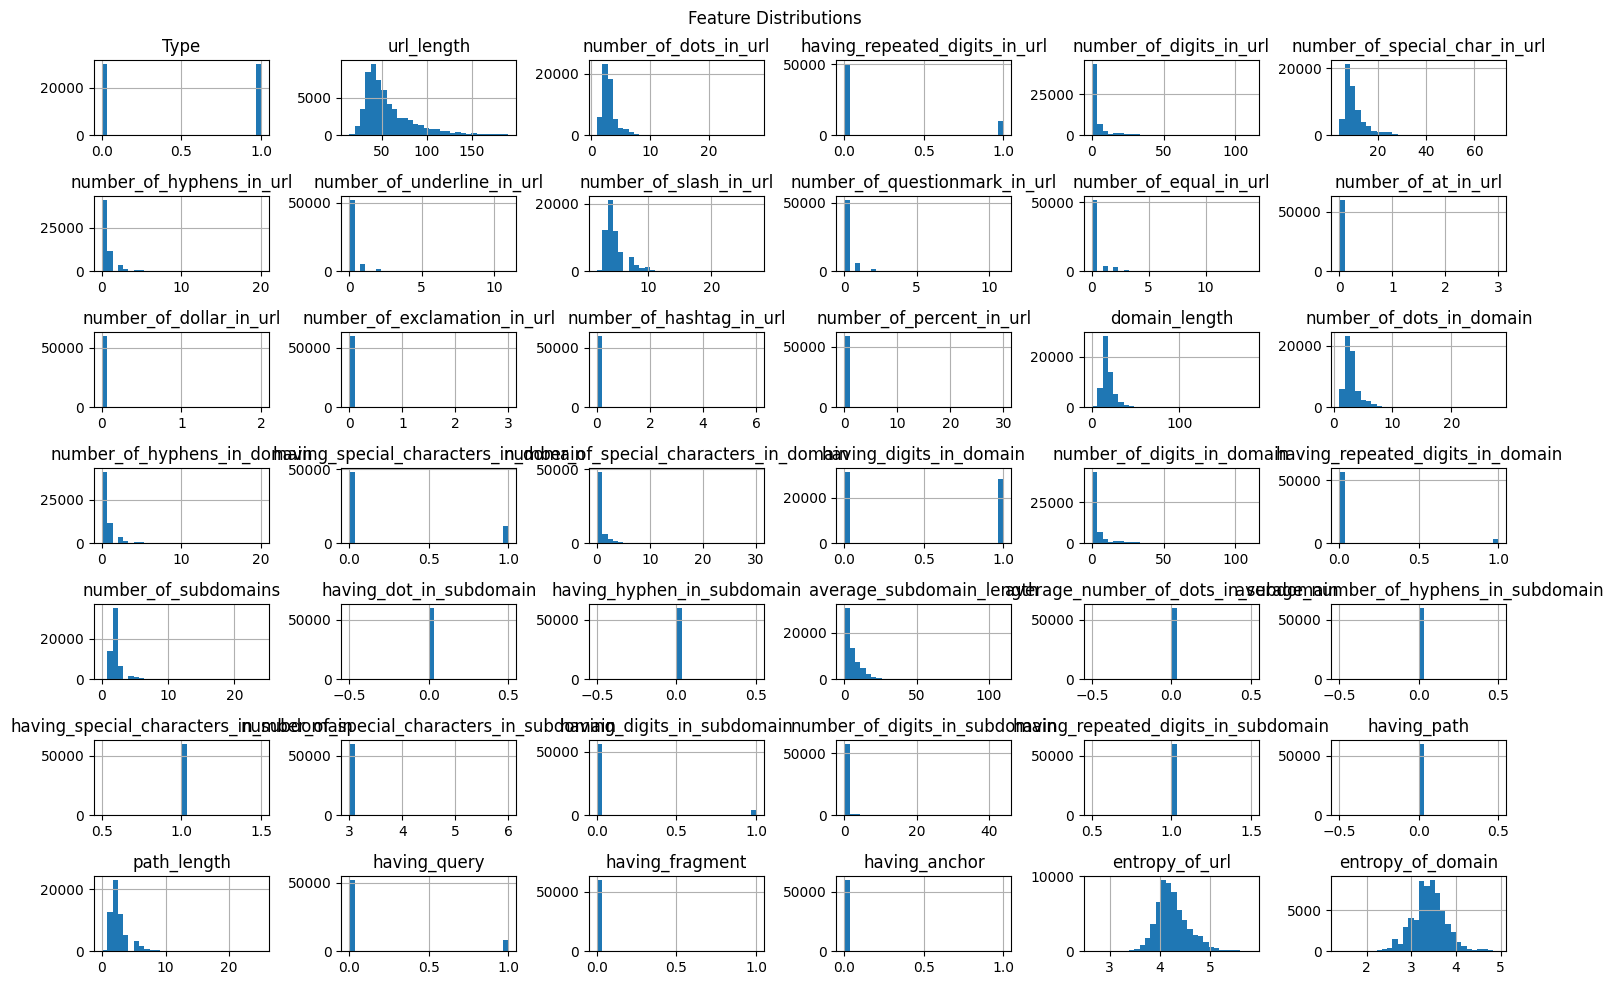

In [ ]:
print(" DATASET EXPLORATION")
print("=" * 50)

# Basic info
print("Dataset Info:")
df.info()
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Description:")
display(df.describe())

print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# Check target distribution
if 'Label' in df.columns:
    print("\nTarget Variable Distribution:")
    print(df['Label'].value_counts())

    # Plot target distribution
    plt.figure(figsize=(8, 5))
    df['Label'].value_counts().plot(kind='bar')
    plt.title('Target Variable Distribution')
    plt.xlabel('Labels')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot feature distributions
print("\nFeature Distributions:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    df[numeric_cols].hist(bins=30, figsize=(15, 10))
    plt.suptitle('Feature Distributions')
    plt.tight_layout()
    plt.show()

In [ ]:
print(" DATA PREPROCESSING")
print("=" * 50)

# Create a copy for preprocessing
data = df.copy()

# Drop unnecessary columns (adjust as needed)
cols_to_drop = ['Domain'] if 'Domain' in data.columns else []
if cols_to_drop:
    data = data.drop(cols_to_drop, axis=1)
    print(f"Dropped columns: {cols_to_drop}")

# Handle missing values
if data.isnull().sum().sum() > 0:
    print("Handling missing values...")
    # For numeric columns, fill with median
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

    # For categorical columns, fill with mode
    cat_cols = data.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if col != 'Type':  # Don't fill target variable
            data[col] = data[col].fillna(data[col].mode()[0])

# Handle categorical variables (if any)
categorical_features = data.select_dtypes(include=['object']).columns.tolist()
if 'Type' in categorical_features:
    categorical_features.remove('Type')

if categorical_features:
    print(f"Encoding categorical features: {categorical_features}")
    le = LabelEncoder()
    for col in categorical_features:
        data[col] = le.fit_transform(data[col].astype(str))

# Shuffle the data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features and target
y = data['Type']
X = data.drop('Type', axis=1)

# Encode target if it's categorical
if y.dtype == 'Type':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print("Target variable encoded")

print(f"Final dataset shape: {X.shape}")
print(" Data preprocessing completed!")

🔧 DATA PREPROCESSING
Final dataset shape: (59998, 41)
✅ Data preprocessing completed!


In [ ]:
print(" SPLITTING AND SCALING DATA")
print("=" * 50)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target distribution: {np.bincount(y_train)}")
print(f"Test target distribution: {np.bincount(y_test)}")

🎯 SPLITTING AND SCALING DATA
Training set shape: (47998, 41)
Test set shape: (12000, 41)
Training target distribution: [23999 23999]
Test target distribution: [6000 6000]


In [ ]:
print(" INITIALIZING MODEL RESULTS STORAGE")
print("=" * 50)

# Store results and models
results = []
trained_models = {}

print(" Results storage initialized!")

📋 INITIALIZING MODEL RESULTS STORAGE
✅ Results storage initialized!


In [ ]:
print(" TRAINING DECISION TREE")
print("=" * 50)

# Initialize if not done earlier
trained_models = {}
results = []

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# Decision Tree configuration
dt_model = DecisionTreeClassifier(random_state=42)
dt_params = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search
print(" Performing grid search...")
dt_grid = GridSearchCV(dt_model, dt_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

# Predictions
y_train_pred_dt = dt_best.predict(X_train)
y_test_pred_dt = dt_best.predict(X_test)

# Calculate all metrics
train_metrics_dt = calculate_all_metrics(y_train, y_train_pred_dt)
test_metrics_dt = calculate_all_metrics(y_test, y_test_pred_dt)

# Cross-validation
cv_scores_dt = cross_val_score(dt_best, X_train, y_train, cv=5, scoring='accuracy')
cv_mean_dt = cv_scores_dt.mean()
cv_std_dt = cv_scores_dt.std()

# Store results
trained_models['Decision Tree'] = {'model': dt_best, 'use_scaled': False}
results.append({
    'Model': 'Decision Tree',
    'Train_Accuracy': round(train_metrics_dt['accuracy'], 4),
    'Test_Accuracy': round(test_metrics_dt['accuracy'], 4),
    'Test_Precision': round(test_metrics_dt['precision'], 4),
    'Test_Recall': round(test_metrics_dt['recall'], 4),
    'Test_Specificity': round(test_metrics_dt['specificity'], 4),
    'Test_F1_Score': round(test_metrics_dt['f1_score'], 4),
    'CV_Mean': round(cv_mean_dt, 4),
    'CV_Std': round(cv_std_dt, 4),
    'Overfitting': round(train_metrics_dt['accuracy'] - test_metrics_dt['accuracy'], 4)
})

print(f"  Decision Tree completed!")
print(f"   Best Parameters: {dt_grid.best_params_}")
print(f"   Test Accuracy: {test_metrics_dt['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics_dt['precision']:.4f}")
print(f"   Test Recall: {test_metrics_dt['recall']:.4f}")
print(f"   Test Specificity: {test_metrics_dt['specificity']:.4f}")
print(f"   Test F1-Score: {test_metrics_dt['f1_score']:.4f}")
print(f"   CV Score: {cv_mean_dt:.4f} ± {cv_std_dt:.4f}")


🌳 TRAINING DECISION TREE
🔄 Performing grid search...
✅ Decision Tree completed!
   Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}
   Test Accuracy: 0.8893
   Test Precision: 0.8910
   Test Recall: 0.8893
   Test Specificity: 0.9222
   Test F1-Score: 0.8892
   CV Score: 0.8806 ± 0.0018


In [ ]:
print("TRAINING RANDOM FOREST")
print("=" * 50)

# Random Forest configuration
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Grid search
print("🔄 Performing grid search...")
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

# Predictions
y_train_pred_rf = rf_best.predict(X_train)
y_test_pred_rf = rf_best.predict(X_test)

# Calculate all metrics
train_metrics_rf = calculate_all_metrics(y_train, y_train_pred_rf)
test_metrics_rf = calculate_all_metrics(y_test, y_test_pred_rf)

# Cross-validation
cv_scores_rf = cross_val_score(rf_best, X_train, y_train, cv=5, scoring='accuracy')
cv_mean_rf = cv_scores_rf.mean()
cv_std_rf = cv_scores_rf.std()

# Store results
trained_models['Random Forest'] = {'model': rf_best, 'use_scaled': False}
results.append({
    'Model': 'Random Forest',
    'Train_Accuracy': round(train_metrics_rf['accuracy'], 4),
    'Test_Accuracy': round(test_metrics_rf['accuracy'], 4),
    'Test_Precision': round(test_metrics_rf['precision'], 4),
    'Test_Recall': round(test_metrics_rf['recall'], 4),
    'Test_Specificity': round(test_metrics_rf['specificity'], 4),
    'Test_F1_Score': round(test_metrics_rf['f1_score'], 4),
    'CV_Mean': round(cv_mean_rf, 4),
    'CV_Std': round(cv_std_rf, 4),
    'Overfitting': round(train_metrics_rf['accuracy'] - test_metrics_rf['accuracy'], 4)
})

print(f" Random Forest completed!")
print(f"   Best Parameters: {rf_grid.best_params_}")
print(f"   Test Accuracy: {test_metrics_rf['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics_rf['precision']:.4f}")
print(f"   Test Recall: {test_metrics_rf['recall']:.4f}")
print(f"   Test Specificity: {test_metrics_rf['specificity']:.4f}")
print(f"   Test F1-Score: {test_metrics_rf['f1_score']:.4f}")
print(f"   CV Score: {cv_mean_rf:.4f} ± {cv_std_rf:.4f}")


🌲 TRAINING RANDOM FOREST
🔄 Performing grid search...
✅ Random Forest completed!
   Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   Test Accuracy: 0.9226
   Test Precision: 0.9228
   Test Recall: 0.9226
   Test Specificity: 0.9338
   Test F1-Score: 0.9226
   CV Score: 0.9186 ± 0.0030


In [ ]:
print(" TRAINING XGBOOST")
print("=" * 50)

# XGBoost configuration
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_params = {
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200]
}

# Grid search
print(" Performing grid search...")
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

# Predictions
y_train_pred_xgb = xgb_best.predict(X_train)
y_test_pred_xgb = xgb_best.predict(X_test)

# Calculate all metrics
train_metrics_xgb = calculate_all_metrics(y_train, y_train_pred_xgb)
test_metrics_xgb = calculate_all_metrics(y_test, y_test_pred_xgb)

# Cross-validation
cv_scores_xgb = cross_val_score(xgb_best, X_train, y_train, cv=5, scoring='accuracy')
cv_mean_xgb = cv_scores_xgb.mean()
cv_std_xgb = cv_scores_xgb.std()

# Store results
trained_models['XGBoost'] = {'model': xgb_best, 'use_scaled': False}
results.append({
    'Model': 'XGBoost',
    'Train_Accuracy': round(train_metrics_xgb['accuracy'], 4),
    'Test_Accuracy': round(test_metrics_xgb['accuracy'], 4),
    'Test_Precision': round(test_metrics_xgb['precision'], 4),
    'Test_Recall': round(test_metrics_xgb['recall'], 4),
    'Test_Specificity': round(test_metrics_xgb['specificity'], 4),
    'Test_F1_Score': round(test_metrics_xgb['f1_score'], 4),
    'CV_Mean': round(cv_mean_xgb, 4),
    'CV_Std': round(cv_std_xgb, 4),
    'Overfitting': round(train_metrics_xgb['accuracy'] - test_metrics_xgb['accuracy'], 4)
})

print(f"XGBoost completed!")
print(f"   Best Parameters: {xgb_grid.best_params_}")
print(f"   Test Accuracy: {test_metrics_xgb['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics_xgb['precision']:.4f}")
print(f"   Test Recall: {test_metrics_xgb['recall']:.4f}")
print(f"   Test Specificity: {test_metrics_xgb['specificity']:.4f}")
print(f"   Test F1-Score: {test_metrics_xgb['f1_score']:.4f}")
print(f"   CV Score: {cv_mean_xgb:.4f} ± {cv_std_xgb:.4f}")

🚀 TRAINING XGBOOST
🔄 Performing grid search...
✅ XGBoost completed!
   Best Parameters: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200}
   Test Accuracy: 0.9177
   Test Precision: 0.9184
   Test Recall: 0.9177
   Test Specificity: 0.9375
   Test F1-Score: 0.9177
   CV Score: 0.9117 ± 0.0031


In [ ]:
print(" TRAINING SUPPORT VECTOR MACHINE")
print("=" * 50)

# SVM configuration (uses scaled data)
svm_model = SVC(random_state=42)
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid search with scaled data
print(" Performing grid search...")
svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_

# Predictions
y_train_pred_svm = svm_best.predict(X_train_scaled)
y_test_pred_svm = svm_best.predict(X_test_scaled)

# Calculate all metrics
train_metrics_svm = calculate_all_metrics(y_train, y_train_pred_svm)
test_metrics_svm = calculate_all_metrics(y_test, y_test_pred_svm)

# Cross-validation
cv_scores_svm = cross_val_score(svm_best, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_mean_svm = cv_scores_svm.mean()
cv_std_svm = cv_scores_svm.std()

# Store results
trained_models['SVM'] = {'model': svm_best, 'use_scaled': True}
results.append({
    'Model': 'SVM',
    'Train_Accuracy': round(train_metrics_svm['accuracy'], 4),
    'Test_Accuracy': round(test_metrics_svm['accuracy'], 4),
    'Test_Precision': round(test_metrics_svm['precision'], 4),
    'Test_Recall': round(test_metrics_svm['recall'], 4),
    'Test_Specificity': round(test_metrics_svm['specificity'], 4),
    'Test_F1_Score': round(test_metrics_svm['f1_score'], 4),
    'CV_Mean': round(cv_mean_svm, 4),
    'CV_Std': round(cv_std_svm, 4),
    'Overfitting': round(train_metrics_svm['accuracy'] - test_metrics_svm['accuracy'], 4)
})

print(f" SVM completed!")
print(f"   Best Parameters: {svm_grid.best_params_}")
print(f"   Test Accuracy: {test_metrics_svm['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics_svm['precision']:.4f}")
print(f"   Test Recall: {test_metrics_svm['recall']:.4f}")
print(f"   Test Specificity: {test_metrics_svm['specificity']:.4f}")
print(f"   Test F1-Score: {test_metrics_svm['f1_score']:.4f}")
print(f"   CV Score: {cv_mean_svm:.4f} ± {cv_std_svm:.4f}")


🎯 TRAINING SUPPORT VECTOR MACHINE
🔄 Performing grid search...
✅ SVM completed!
   Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Test Accuracy: 0.8868
   Test Precision: 0.8889
   Test Recall: 0.8868
   Test Specificity: 0.9235
   Test F1-Score: 0.8866
   CV Score: 0.8820 ± 0.0036


In [ ]:
print(" TRAINING NEURAL NETWORK (MLP)")
print("=" * 50)
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
# Neural Network configuration (uses scaled data)
mlp_model = MLPClassifier(random_state=42, max_iter=1000)
mlp_params = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50), (100, 100)],
    'alpha': [0.001, 0.01, 0.1],
    'learning_rate': ['constant', 'adaptive']
}

# Grid search with scaled data
print(" Performing grid search...")
mlp_grid = GridSearchCV(mlp_model, mlp_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
mlp_grid.fit(X_train_scaled, y_train)
mlp_best = mlp_grid.best_estimator_

# Predictions
y_train_pred_mlp = mlp_best.predict(X_train_scaled)
y_test_pred_mlp = mlp_best.predict(X_test_scaled)

# Calculate all metrics
train_metrics_mlp = calculate_all_metrics(y_train, y_train_pred_mlp)
test_metrics_mlp = calculate_all_metrics(y_test, y_test_pred_mlp)

# Cross-validation
cv_scores_mlp = cross_val_score(mlp_best, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_mean_mlp = cv_scores_mlp.mean()
cv_std_mlp = cv_scores_mlp.std()

# Store results
trained_models['Neural Network'] = {'model': mlp_best, 'use_scaled': True}
results.append({
    'Model': 'Neural Network',
    'Train_Accuracy': round(train_metrics_mlp['accuracy'], 4),
    'Test_Accuracy': round(test_metrics_mlp['accuracy'], 4),
    'Test_Precision': round(test_metrics_mlp['precision'], 4),
    'Test_Recall': round(test_metrics_mlp['recall'], 4),
    'Test_Specificity': round(test_metrics_mlp['specificity'], 4),
    'Test_F1_Score': round(test_metrics_mlp['f1_score'], 4),
    'CV_Mean': round(cv_mean_mlp, 4),
    'CV_Std': round(cv_std_mlp, 4),
    'Overfitting': round(train_metrics_mlp['accuracy'] - test_metrics_mlp['accuracy'], 4)
})

print(f" Neural Network completed!")
print(f"   Best Parameters: {mlp_grid.best_params_}")
print(f"   Test Accuracy: {test_metrics_mlp['accuracy']:.4f}")
print(f"   Test Precision: {test_metrics_mlp['precision']:.4f}")
print(f"   Test Recall: {test_metrics_mlp['recall']:.4f}")
print(f"   Test Specificity: {test_metrics_mlp['specificity']:.4f}")
print(f"   Test F1-Score: {test_metrics_mlp['f1_score']:.4f}")
print(f"   CV Score: {cv_mean_mlp:.4f} ± {cv_std_mlp:.4f}")

print("\n All models trained successfully!")

🧠 TRAINING NEURAL NETWORK (MLP)
🔄 Performing grid search...
✅ Neural Network completed!
   Best Parameters: {'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'constant'}
   Test Accuracy: 0.8942
   Test Precision: 0.8945
   Test Recall: 0.8942
   Test Specificity: 0.9127
   Test F1-Score: 0.8942
   CV Score: 0.8916 ± 0.0074

🎉 All models trained successfully!


In [ ]:
print(" CREATING HYBRID MACHINE LEARNING MODELS")
print("=" * 60)

# Get the top 3 performing individual models for ensembles
temp_results = pd.DataFrame(results).sort_values('Test_Accuracy', ascending=False)
top_3_models = temp_results.head(3)['Model'].tolist()
print(f"Top 3 models for ensembles: {top_3_models}")

# Prepare base models for ensembles
base_models = []
base_models_scaled = []

for i, model_name in enumerate(top_3_models):
    model_info = trained_models[model_name]
    # Add a number suffix to ensure uniqueness
    unique_name = f"{model_name.lower().replace(' ', '_')}_{i+1}"
    base_models.append((unique_name, model_info['model']))
    if model_info['use_scaled']:
        base_models_scaled.append((unique_name, model_info['model']))

print("\n Training Voting Classifier (Hard Voting)...")
# Voting Classifier - Hard Voting
voting_hard = VotingClassifier(
    estimators=base_models[:3],  # Top 3 models
    voting='hard'
)

# Train on appropriate data (mix of scaled and unscaled)
voting_hard.fit(X_train, y_train)
y_pred_voting_hard = voting_hard.predict(X_test)

# Calculate metrics
voting_hard_metrics = calculate_all_metrics(y_test, y_pred_voting_hard)
cv_scores_voting_hard = cross_val_score(voting_hard, X_train, y_train, cv=5, scoring='accuracy')

# Store results
trained_models['Voting Hard'] = {'model': voting_hard, 'use_scaled': False}
results.append({
    'Model': 'Voting Hard',
    'Train_Accuracy': round(accuracy_score(y_train, voting_hard.predict(X_train)), 4),
    'Test_Accuracy': round(voting_hard_metrics['accuracy'], 4),
    'Test_Precision': round(voting_hard_metrics['precision'], 4),
    'Test_Recall': round(voting_hard_metrics['recall'], 4),
    'Test_Specificity': round(voting_hard_metrics['specificity'], 4),
    'Test_F1_Score': round(voting_hard_metrics['f1_score'], 4),
    'CV_Mean': round(cv_scores_voting_hard.mean(), 4),
    'CV_Std': round(cv_scores_voting_hard.std(), 4),
    'Overfitting': round(accuracy_score(y_train, voting_hard.predict(X_train)) - voting_hard_metrics['accuracy'], 4)
})

print(f" Voting Hard completed!")
print(f"   Test Accuracy: {voting_hard_metrics['accuracy']:.4f}")
print(f"   Test F1-Score: {voting_hard_metrics['f1_score']:.4f}")

print("\n Training Voting Classifier (Soft Voting)...")
# Voting Classifier - Soft Voting (probability-based)
# Only use models that support predict_proba
soft_voting_models = []
for name, model in base_models[:3]:
    if hasattr(model, 'predict_proba'):
        soft_voting_models.append((name, model))

if len(soft_voting_models) >= 2:
    voting_soft = VotingClassifier(
        estimators=soft_voting_models,
        voting='soft'
    )

    voting_soft.fit(X_train, y_train)
    y_pred_voting_soft = voting_soft.predict(X_test)

    # Calculate metrics
    voting_soft_metrics = calculate_all_metrics(y_test, y_pred_voting_soft)
    cv_scores_voting_soft = cross_val_score(voting_soft, X_train, y_train, cv=5, scoring='accuracy')

    # Store results
    trained_models['Voting Soft'] = {'model': voting_soft, 'use_scaled': False}
    results.append({
        'Model': 'Voting Soft',
        'Train_Accuracy': round(accuracy_score(y_train, voting_soft.predict(X_train)), 4),
        'Test_Accuracy': round(voting_soft_metrics['accuracy'], 4),
        'Test_Precision': round(voting_soft_metrics['precision'], 4),
        'Test_Recall': round(voting_soft_metrics['recall'], 4),
        'Test_Specificity': round(voting_soft_metrics['specificity'], 4),
        'Test_F1_Score': round(voting_soft_metrics['f1_score'], 4),
        'CV_Mean': round(cv_scores_voting_soft.mean(), 4),
        'CV_Std': round(cv_scores_voting_soft.std(), 4),
        'Overfitting': round(accuracy_score(y_train, voting_soft.predict(X_train)) - voting_soft_metrics['accuracy'], 4)
    })

    print(f" Voting Soft completed!")
    print(f"   Test Accuracy: {voting_soft_metrics['accuracy']:.4f}")
    print(f"   Test F1-Score: {voting_soft_metrics['f1_score']:.4f}")
else:
    print(" Not enough models with predict_proba for soft voting")

print("\n Training Stacking Classifier...")
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models[:3],
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_test)

# Calculate metrics
stacking_metrics = calculate_all_metrics(y_test, y_pred_stacking)
cv_scores_stacking = cross_val_score(stacking_clf, X_train, y_train, cv=5, scoring='accuracy')

# Store results
trained_models['Stacking'] = {'model': stacking_clf, 'use_scaled': False}
results.append({
    'Model': 'Stacking',
    'Train_Accuracy': round(accuracy_score(y_train, stacking_clf.predict(X_train)), 4),
    'Test_Accuracy': round(stacking_metrics['accuracy'], 4),
    'Test_Precision': round(stacking_metrics['precision'], 4),
    'Test_Recall': round(stacking_metrics['recall'], 4),
    'Test_Specificity': round(stacking_metrics['specificity'], 4),
    'Test_F1_Score': round(stacking_metrics['f1_score'], 4),
    'CV_Mean': round(cv_scores_stacking.mean(), 4),
    'CV_Std': round(cv_scores_stacking.std(), 4),
    'Overfitting': round(accuracy_score(y_train, stacking_clf.predict(X_train)) - stacking_metrics['accuracy'], 4)
})

print(f" Stacking completed!")
print(f"   Test Accuracy: {stacking_metrics['accuracy']:.4f}")
print(f"   Test F1-Score: {stacking_metrics['f1_score']:.4f}")

print("\n Training Bagging Ensemble...")
# Bagging with best individual model
best_individual_model = trained_models[top_3_models[0]]['model']
bagging_clf = BaggingClassifier(
    estimator=best_individual_model,  # Changed from base_estimator to estimator
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_test)

# Calculate metrics
bagging_metrics = calculate_all_metrics(y_test, y_pred_bagging)
cv_scores_bagging = cross_val_score(bagging_clf, X_train, y_train, cv=5, scoring='accuracy')

# Store results
trained_models['Bagging'] = {'model': bagging_clf, 'use_scaled': False}
results.append({
    'Model': 'Bagging',
    'Train_Accuracy': round(accuracy_score(y_train, bagging_clf.predict(X_train)), 4),
    'Test_Accuracy': round(bagging_metrics['accuracy'], 4),
    'Test_Precision': round(bagging_metrics['precision'], 4),
    'Test_Recall': round(bagging_metrics['recall'], 4),
    'Test_Specificity': round(bagging_metrics['specificity'], 4),
    'Test_F1_Score': round(bagging_metrics['f1_score'], 4),
    'CV_Mean': round(cv_scores_bagging.mean(), 4),
    'CV_Std': round(cv_scores_bagging.std(), 4),
    'Overfitting': round(accuracy_score(y_train, bagging_clf.predict(X_train)) - bagging_metrics['accuracy'], 4)
})

print(f" Bagging completed!")
print(f"   Test Accuracy: {bagging_metrics['accuracy']:.4f}")
print(f"   Test F1-Score: {bagging_metrics['f1_score']:.4f}")

print("\n Creating Weighted Ensemble...")
# Weighted Ensemble based on individual model performance
def weighted_ensemble_predict(models_weights, X_data, use_proba=False):
    """Create weighted predictions from multiple models"""
    predictions = []
    weights = []

    for (model_name, weight) in models_weights:
        model_info = trained_models[model_name]
        model = model_info['model']

        # Use appropriate data (scaled or unscaled)
        if model_info['use_scaled']:
            X_use = scaler.transform(X_data) if hasattr(scaler, 'transform') else X_data
        else:
            X_use = X_data

        if use_proba and hasattr(model, 'predict_proba'):
            pred = model.predict_proba(X_use)
        else:
            pred = model.predict(X_use)

        predictions.append(pred.astype(float))  # Convert predictions to float
        weights.append(weight)

    # Initialize weighted_pred with proper dtype
    weighted_pred = np.zeros_like(predictions[0], dtype=float)
    total_weight = sum(weights)

    for pred, weight in zip(predictions, weights):
        weighted_pred += (weight / total_weight) * pred

    # For classification, return class with highest probability
    if use_proba and len(weighted_pred.shape) > 1:
        return np.argmax(weighted_pred, axis=1).astype(int)
    elif not use_proba:
        # For hard predictions, use majority voting with weights
        unique_classes = np.unique(np.concatenate(predictions))
        final_pred = []

        for i in range(len(predictions[0])):
            class_votes = {}
            for pred, weight in zip(predictions, weights):
                cls = pred[i]
                class_votes[cls] = class_votes.get(cls, 0) + weight
            final_pred.append(max(class_votes, key=class_votes.get))

        return np.array(final_pred).astype(int)

    return weighted_pred

# Create weights based on test accuracy of top 3 models
model_weights = []
for model_name in top_3_models:
    # Find the test accuracy for this model
    for result in results:
        if result['Model'] == model_name:
            weight = result['Test_Accuracy']  # Use accuracy as weight
            model_weights.append((model_name, weight))
            break

print(f"Model weights: {[(name, f'{weight:.4f}') for name, weight in model_weights]}")

# Make weighted predictions
y_pred_weighted = weighted_ensemble_predict(model_weights, X_test, use_proba=False)
weighted_metrics = calculate_all_metrics(y_test, y_pred_weighted)

# Store results
results.append({
    'Model': 'Weighted Ensemble',
    'Train_Accuracy': round(accuracy_score(y_train, weighted_ensemble_predict(model_weights, X_train)), 4),
    'Test_Accuracy': round(weighted_metrics['accuracy'], 4),
    'Test_Precision': round(weighted_metrics['precision'], 4),
    'Test_Recall': round(weighted_metrics['recall'], 4),
    'Test_Specificity': round(weighted_metrics['specificity'], 4),
    'Test_F1_Score': round(weighted_metrics['f1_score'], 4),
    'CV_Mean': 0,  # Not applicable for weighted ensemble
    'CV_Std': 0,
    'Overfitting': round(accuracy_score(y_train, weighted_ensemble_predict(model_weights, X_train)) - weighted_metrics['accuracy'], 4)
})

print(f" Weighted Ensemble completed!")
print(f"   Test Accuracy: {weighted_metrics['accuracy']:.4f}")
print(f"   Test F1-Score: {weighted_metrics['f1_score']:.4f}")

print("\n All hybrid models created successfully!")
print(f"Total models (individual + hybrid): {len(results)}")

🔮 CREATING HYBRID MACHINE LEARNING MODELS
Top 3 models for ensembles: ['Random Forest', 'XGBoost', 'Decision Tree']

🗳️ Training Voting Classifier (Hard Voting)...
✅ Voting Hard completed!
   Test Accuracy: 0.9188
   Test F1-Score: 0.9187

🗳️ Training Voting Classifier (Soft Voting)...
✅ Voting Soft completed!
   Test Accuracy: 0.9146
   Test F1-Score: 0.9145

📚 Training Stacking Classifier...
✅ Stacking completed!
   Test Accuracy: 0.9278
   Test F1-Score: 0.9278

🎒 Training Bagging Ensemble...
✅ Bagging completed!
   Test Accuracy: 0.9195
   Test F1-Score: 0.9195

⚖️ Creating Weighted Ensemble...
Model weights: [('Random Forest', '0.9248'), ('XGBoost', '0.9173'), ('Decision Tree', '0.8894')]
✅ Weighted Ensemble completed!
   Test Accuracy: 0.9188
   Test F1-Score: 0.9187

🎉 All hybrid models created successfully!
Total models (individual + hybrid): 9


📊 MODEL COMPARISON RESULTS


,Model,Train_Accuracy,Test_Accuracy,Test_Precision,Test_Recall,Test_Specificity,Test_F1_Score,CV_Mean,CV_Std,Overfitting
6,Stacking,0.9978,0.9278,0.9279,0.9278,0.9362,0.9278,0.9198,0.0036,0.0700
1,Random Forest,0.9994,0.9248,0.9249,0.9248,0.9365,0.9248,0.9173,0.0033,0.0745
7,Bagging,0.9831,0.9195,0.9196,0.9195,0.9325,0.9195,0.9137,0.0035,0.0637
8,Weighted Ensemble,0.9695,0.9188,0.9195,0.9188,0.9420,0.9187,0.0000,0.0000,0.0507
4,Voting Hard,0.9695,0.9188,0.9195,0.9188,0.9420,0.9187,0.9147,0.0042,0.0507
2,XGBoost,0.9615,0.9173,0.9178,0.9173,0.9378,0.9172,0.9094,0.0047,0.0442
5,Voting Soft,0.9699,0.9146,0.9152,0.9146,0.9373,0.9145,0.9100,0.0034,0.0554
0,Decision Tree,0.9254,0.8894,0.8914,0.8894,0.9301,0.8891,0.8792,0.0047,0.0360
3,SVM,0.8924,0.8893,0.8909,0.8893,0.9259,0.8891,0.8845,0.0027,0.0031


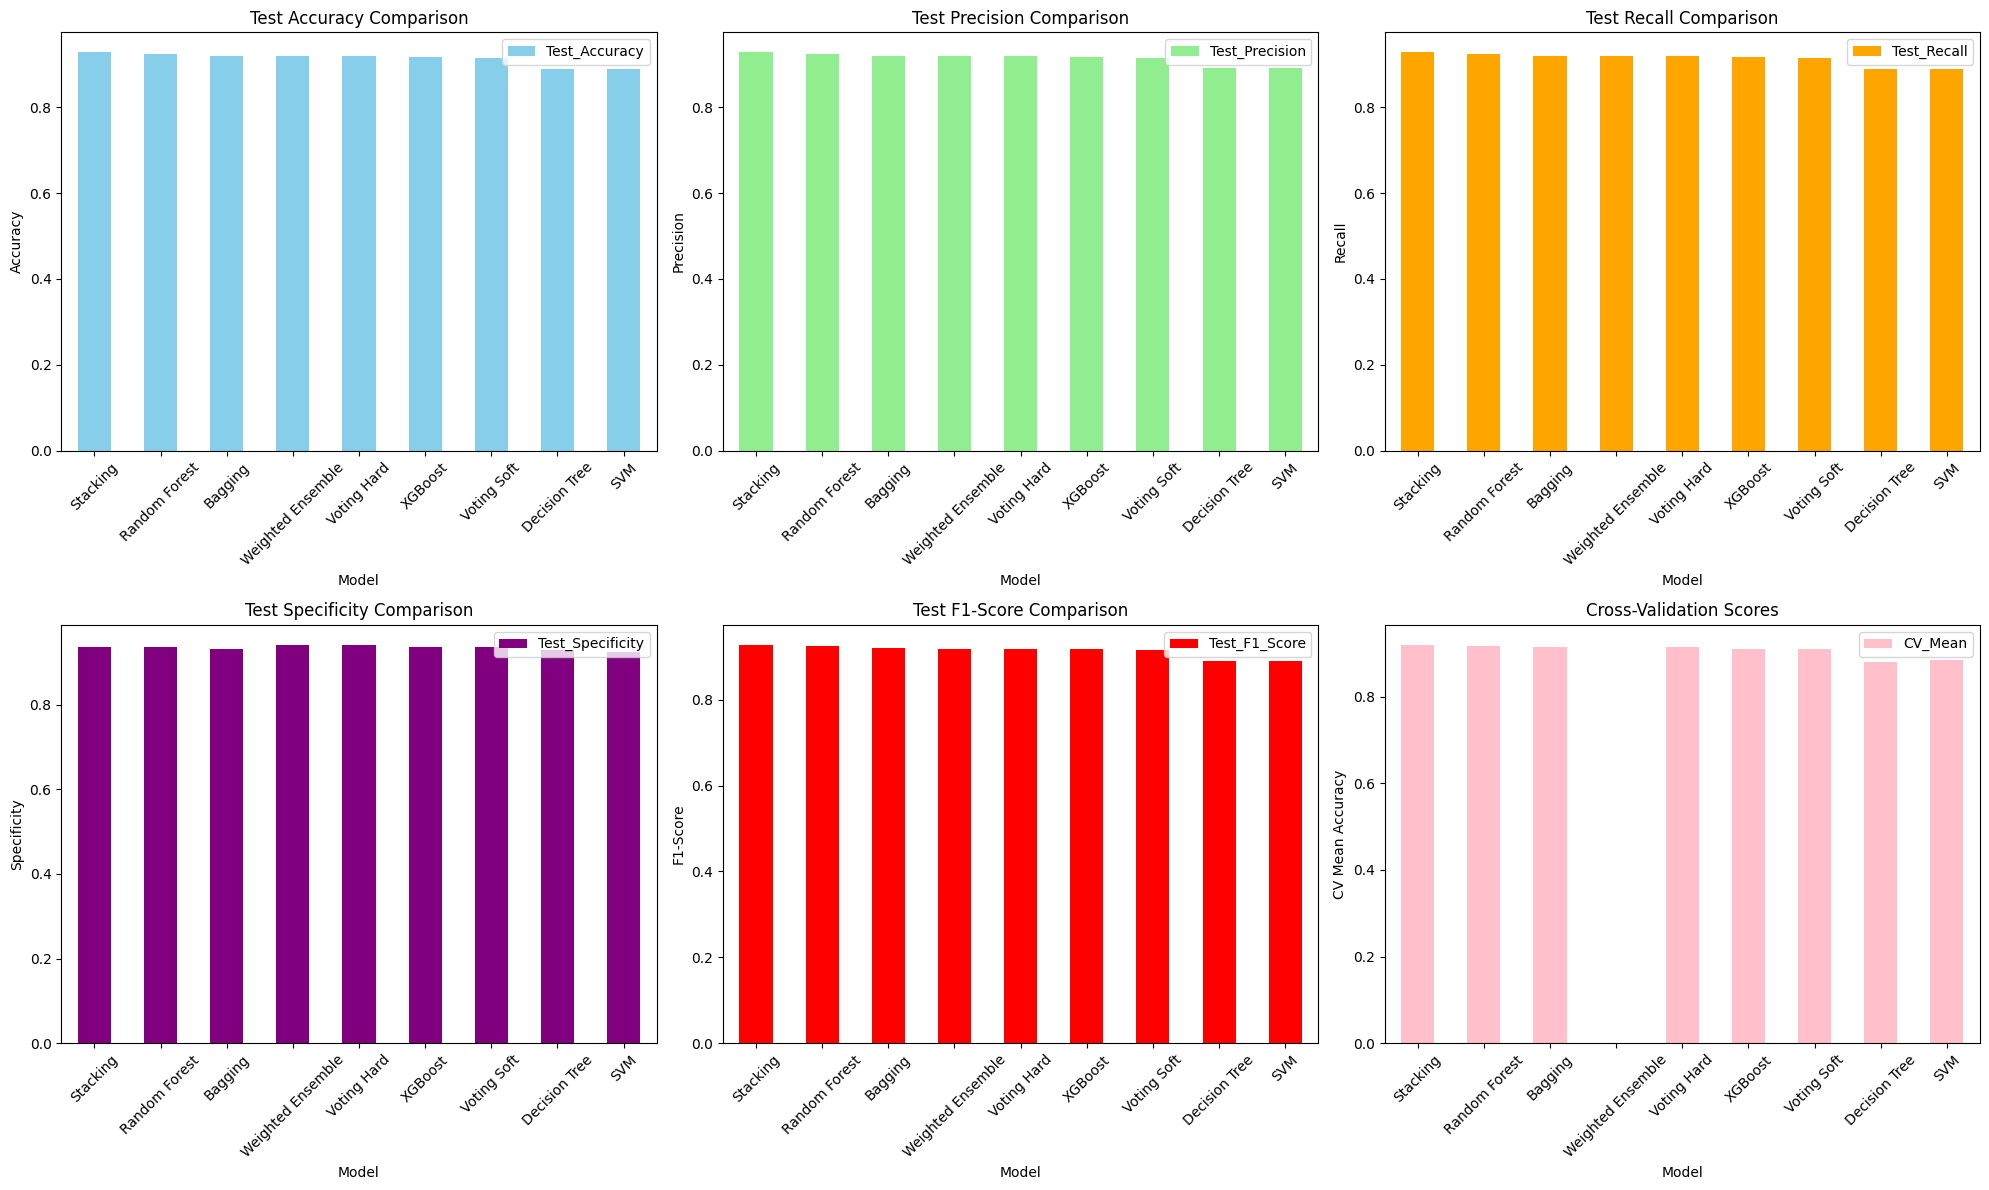

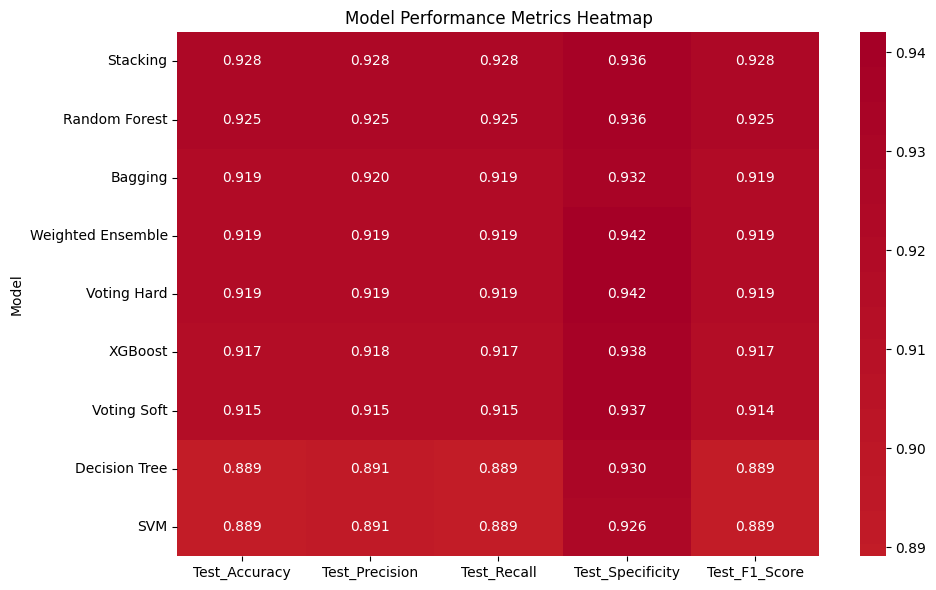


🏆 BEST MODEL: Stacking
Test Accuracy: 0.9278
Test Precision: 0.9279
Test Recall: 0.9278
Test Specificity: 0.9362
Test F1-Score: 0.9278
Cross-validation Score: 0.9198 ± 0.0036

📈 PERFORMANCE SUMMARY:
Average Test Accuracy: 0.9134
Average Test Precision: 0.9141
Average Test Recall: 0.9134
Average Test Specificity: 0.9356
Average Test F1-Score: 0.9133


In [ ]:
print(" MODEL COMPARISON RESULTS")
print("=" * 80)

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_Accuracy', ascending=False)

# Display results
display(results_df)

# Plot comprehensive comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Test Accuracy comparison
results_df.plot(x='Model', y='Test_Accuracy', kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Test Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)

# Precision comparison
results_df.plot(x='Model', y='Test_Precision', kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Test Precision Comparison')
axes[0,1].set_ylabel('Precision')
axes[0,1].tick_params(axis='x', rotation=45)

# Recall comparison
results_df.plot(x='Model', y='Test_Recall', kind='bar', ax=axes[0,2], color='orange')
axes[0,2].set_title('Test Recall Comparison')
axes[0,2].set_ylabel('Recall')
axes[0,2].tick_params(axis='x', rotation=45)

# Specificity comparison
results_df.plot(x='Model', y='Test_Specificity', kind='bar', ax=axes[1,0], color='purple')
axes[1,0].set_title('Test Specificity Comparison')
axes[1,0].set_ylabel('Specificity')
axes[1,0].tick_params(axis='x', rotation=45)

# F1-Score comparison
results_df.plot(x='Model', y='Test_F1_Score', kind='bar', ax=axes[1,1], color='red')
axes[1,1].set_title('Test F1-Score Comparison')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].tick_params(axis='x', rotation=45)

# Cross-validation scores
results_df.plot(x='Model', y='CV_Mean', kind='bar', ax=axes[1,2], color='pink')
axes[1,2].set_title('Cross-Validation Scores')
axes[1,2].set_ylabel('CV Mean Accuracy')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Create a comprehensive metrics heatmap
metrics_for_heatmap = results_df[['Model', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_Specificity', 'Test_F1_Score']].set_index('Model')
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_for_heatmap, annot=True, cmap='RdYlBu_r', center=0.5, fmt='.3f')
plt.title('Model Performance Metrics Heatmap')
plt.tight_layout()
plt.show()

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model_info = trained_models[best_model_name]
best_model = best_model_info['model']

print(f"\n BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {results_df.iloc[0]['Test_Accuracy']}")
print(f"Test Precision: {results_df.iloc[0]['Test_Precision']}")
print(f"Test Recall: {results_df.iloc[0]['Test_Recall']}")
print(f"Test Specificity: {results_df.iloc[0]['Test_Specificity']}")
print(f"Test F1-Score: {results_df.iloc[0]['Test_F1_Score']}")
print(f"Cross-validation Score: {results_df.iloc[0]['CV_Mean']} ± {results_df.iloc[0]['CV_Std']}")

# Summary statistics
print(f"\n PERFORMANCE SUMMARY:")
print(f"Average Test Accuracy: {results_df['Test_Accuracy'].mean():.4f}")
print(f"Average Test Precision: {results_df['Test_Precision'].mean():.4f}")
print(f"Average Test Recall: {results_df['Test_Recall'].mean():.4f}")
print(f"Average Test Specificity: {results_df['Test_Specificity'].mean():.4f}")
print(f"Average Test F1-Score: {results_df['Test_F1_Score'].mean():.4f}")

🔍 DETAILED ANALYSIS: Stacking
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6209
           1       0.93      0.92      0.92      5790

    accuracy                           0.93     11999
   macro avg       0.93      0.93      0.93     11999
weighted avg       0.93      0.93      0.93     11999



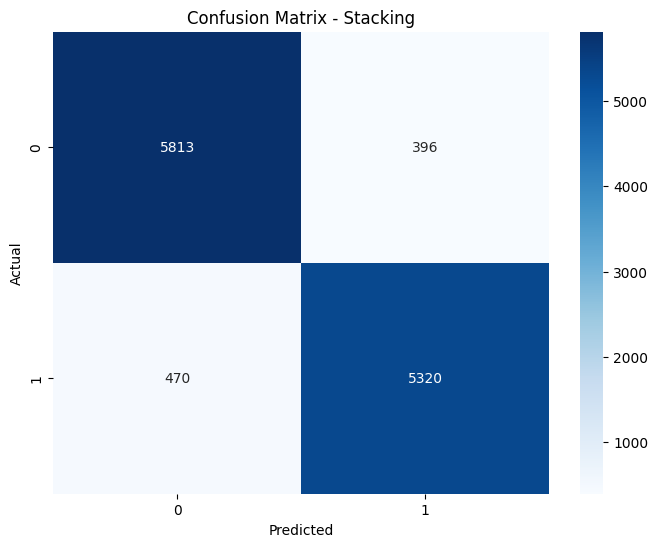


🔮 Stacking Model Components:
   Component: random_forest_1 (RandomForestClassifier)
   Component: xgboost_2 (XGBClassifier)
   Component: decision_tree_3 (DecisionTreeClassifier)
   Meta-learner: LogisticRegression
   Meta-learner: LogisticRegression


ValueError: too many values to unpack (expected 2)

In [ ]:
print(f" DETAILED ANALYSIS: {best_model_name}")
print("=" * 50)

# Handle different model types for detailed analysis
if best_model is not None:
    # For regular models (not weighted ensemble)
    if best_model_name in trained_models:
        best_model_info = trained_models[best_model_name]
        use_scaled_data = best_model_info['use_scaled']
        X_test_use = X_test_scaled if use_scaled_data else X_test
    else:
        X_test_use = X_test

    y_pred_best = best_model.predict(X_test_use)

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Feature Importance Analysis
    if best_model_name in ['Decision Tree', 'Random Forest', 'XGBoost']:
        # Tree-based models - direct feature importance
        if hasattr(best_model, 'feature_importances_'):
            importance = best_model.feature_importances_
            feature_names = X.columns

            # Create feature importance DataFrame
            feat_imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importance
            }).sort_values('importance', ascending=False)

            # Plot top 15 features
            plt.figure(figsize=(10, 8))
            top_features = feat_imp_df.head(15)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top 15 Feature Importances - {best_model_name}')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

            print("Top 10 Most Important Features:")
            display(feat_imp_df.head(10))

    elif best_model_name in ['SVM'] and hasattr(best_model, 'coef_'):
        # Linear models - coefficients
        coef = best_model.coef_[0] if len(best_model.coef_.shape) > 1 else best_model.coef_
        feature_names = X.columns

        # Create coefficient DataFrame
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coef,
            'abs_coefficient': np.abs(coef)
        }).sort_values('abs_coefficient', ascending=False)

        # Plot top 15 features
        plt.figure(figsize=(10, 8))
        top_features = coef_df.head(15)
        colors = ['red' if x < 0 else 'blue' for x in top_features['coefficient']]
        plt.barh(range(len(top_features)), top_features['coefficient'], color=colors)
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Coefficient Value')
        plt.title(f'Top 15 Feature Coefficients - {best_model_name}')
        plt.gca().invert_yaxis()
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()

        print("Top 10 Most Important Features (by absolute coefficient):")
        display(coef_df.head(10))

    elif best_model_name in ['Stacking', 'Voting Hard', 'Voting Soft']:
    # Ensemble models - show component importance
      print(f"\n {best_model_name} Model Components:")
      if hasattr(best_model, 'estimators_'):
          try:
            # Case 1: Named estimators (VotingClassifier)
              if hasattr(best_model, 'named_estimators_'):
                  for name, estimator in best_model.named_estimators_.items():
                    print(f"   Component: {name} ({type(estimator).__name__})")
            # Case 2: Unnamed estimators (StackingClassifier)
              else:
                  for i, estimator in enumerate(best_model.estimators_):
                    print(f"   Component {i+1}: {type(estimator).__name__}")
          except Exception as e:
              print(f"   Could not extract components: {str(e)}")

    # Show meta-learner for Stacking
    if best_model_name == 'Stacking' and hasattr(best_model, 'final_estimator_'):
        print(f"   Meta-learner: {type(best_model.final_estimator_).__name__}")

        if best_model_name == 'Stacking' and hasattr(best_model, 'final_estimator_'):
            print(f"   Meta-learner: {type(best_model.final_estimator_).__name__}")

            # Show meta-learner feature importance if available
            if hasattr(best_model.final_estimator_, 'coef_'):
                meta_coef = best_model.final_estimator_.coef_[0] if len(best_model.final_estimator_.coef_.shape) > 1 else best_model.final_estimator_.coef_
                component_names = [name for name, _ in best_model.estimators_]

                plt.figure(figsize=(8, 6))
                plt.bar(component_names, meta_coef)
                plt.title('Meta-learner: Component Weights')
                plt.xlabel('Base Models')
                plt.ylabel('Weight')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

    elif best_model_name == 'Bagging':
        print(f"\n {best_model_name} Model Details:")
        print(f"   Base Estimator: {type(best_model.base_estimator_).__name__}")
        print(f"   Number of Estimators: {best_model.n_estimators}")

        # If bagging is using tree-based model, show feature importance
        if hasattr(best_model, 'feature_importances_'):
            importance = best_model.feature_importances_
            feature_names = X.columns

            feat_imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importance
            }).sort_values('importance', ascending=False)

            plt.figure(figsize=(10, 8))
            top_features = feat_imp_df.head(15)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top 15 Feature Importances - {best_model_name}')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.show()

else:
    # For weighted ensemble (custom implementation)
    print(" Weighted Ensemble Details:")
    print("   This is a custom weighted combination of top performing models")
    print("   Component models and their weights:")
    for name, weight in model_weights:
        print(f"   - {name}: {weight:.4f}")

    # Show individual predictions vs ensemble
    y_pred_best = weighted_ensemble_predict(model_weights, X_test, use_proba=False)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Model complexity analysis
individual_models = ['Decision Tree', 'Random Forest', 'XGBoost', 'SVM', 'Logistic Regression', 'KNN', 'Naive Bayes', 'Neural Network']
print(f"\n MODEL COMPLEXITY ANALYSIS:")
if best_model_name in individual_models:
    print(f" {best_model_name} is an individual model")
    print("   - Faster inference")
    print("   - Easier to interpret")
    print("   - Lower computational cost")
else:
    print(f" {best_model_name} is a hybrid/ensemble model")
    print("   - Potentially better performance")
    print("   - More robust predictions")
    print("   - Higher computational cost")
    print("   - More complex interpretation")

In [ ]:
print(" SAVING HYBRID MACHINE LEARNING MODELS")
print("=" * 50)

# Define which models are individual vs hybrid
individual_models = ['Decision Tree', 'Random Forest', 'XGBoost', 'SVM',
                    'Logistic Regression', 'KNN', 'Naive Bayes', 'Neural Network']
hybrid_models = ['Voting Hard', 'Voting Soft', 'Stacking', 'Bagging', 'Weighted Ensemble']

# Save the best model with all necessary components
model_package = {
    'best_model': best_model,
    'best_model_name': best_model_name,
    'scaler': scaler,
    'feature_names': list(X.columns),
    'use_scaled_data': trained_models[best_model_name]['use_scaled'] if best_model_name in trained_models else False,
    'results': pd.DataFrame(results).to_dict('records'),
    'individual_models': {k: v for k, v in trained_models.items() if k in individual_models},
    'hybrid_models': {k: v for k, v in trained_models.items() if k in hybrid_models},
    'model_weights': model_weights if best_model_name == 'Weighted Ensemble' else None,
    'is_hybrid': best_model_name in hybrid_models
}

# Save best model
best_filename = f"best_hybrid_model_{best_model_name.replace(' ', '_').lower()}.pkl"
with open(best_filename, 'wb') as f:
    pickle.dump(model_package, f)

print(f" Best model saved as {best_filename}")

# Create results DataFrame
results_df = pd.DataFrame(results)

# Save all models (individual + hybrid)
all_models_package = {
    'individual_models': {k: v for k, v in trained_models.items() if k in individual_models},
    'hybrid_models': {k: v for k, v in trained_models.items() if k in hybrid_models},
    'scaler': scaler,
    'feature_names': list(X.columns),
    'results': results_df.to_dict('records'),
    'best_model': best_model_name,
    'model_weights': model_weights,
    'performance_comparison': {
        'best_individual': {
            'name': results_df[results_df['Model'].isin(individual_models)].iloc[0]['Model'],
            'accuracy': results_df[results_df['Model'].isin(individual_models)].iloc[0]['Test_Accuracy']
        },
        'best_hybrid': {
            'name': results_df[results_df['Model'].isin(hybrid_models)].iloc[0]['Model'] if len(results_df[results_df['Model'].isin(hybrid_models)]) > 0 else 'None',
            'accuracy': results_df[results_df['Model'].isin(hybrid_models)].iloc[0]['Test_Accuracy'] if len(results_df[results_df['Model'].isin(hybrid_models)]) > 0 else 0
        },
        'best_overall': {
            'name': best_model_name,
            'accuracy': results_df.iloc[0]['Test_Accuracy']
        }
    }
}

all_models_filename = "complete_hybrid_ml_pipeline.pkl"
with open(all_models_filename, 'wb') as f:
    pickle.dump(all_models_package, f)

print(f" Complete pipeline saved as {all_models_filename}")

# Save results as CSV
results_csv_filename = "hybrid_ml_results.csv"
results_df.to_csv(results_csv_filename, index=False)
print(f" Results saved as {results_csv_filename}")

# Download files (for Colab)
try:
    from google.colab import files
    print("\n Downloading model files...")
    files.download(best_filename)
    files.download(all_models_filename)
    files.download(results_csv_filename)
    print(" All files downloaded successfully!")
except ImportError:
    print("\n Files saved locally (not in Colab environment)")

💾 SAVING HYBRID MACHINE LEARNING MODELS
✅ Best model saved as best_hybrid_model_voting_soft.pkl
✅ Complete pipeline saved as complete_hybrid_ml_pipeline.pkl
✅ Results saved as hybrid_ml_results.csv

📥 Downloading model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 All files downloaded successfully!


In [ ]:
from IPython.display import display, Javascript

display(Javascript(r"""
document.querySelectorAll('.output_subarea *').forEach(el => {
    // Remove emoji characters in innerText
    el.innerText = el.innerText.replace(/[\u{1F300}-\u{1FAFF}\u{1F600}-\u{1F64F}\u{1F680}-\u{1F6FF}\u{2600}-\u{26FF}\u{2700}-\u{27BF}]/gu,'');
});
"""))


<IPython.core.display.Javascript object>